In [1]:
# make sure jupyter server is installed in the environment
# then install dependencies
%pip install -r requirements.txt --quiet

# make sure all dependencies are installed
import pandas as pd
import nltk
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt

# loading the datasets
negative_df = pd.read_csv('./data/processedNegative.csv', header=None)
positive_df = pd.read_csv('./data/processedPositive.csv', header=None)
neutral_df = pd.read_csv('./data/processedNeutral.csv', header=None)

# transposing the datasets to have tweets in rows
negative_df = negative_df.transpose().rename(columns={0: 'tweet'})
positive_df = positive_df.transpose().rename(columns={0: 'tweet'})
neutral_df = neutral_df.transpose().rename(columns={0: 'tweet'})

# drop any rows with missing values
negative_df = negative_df.dropna().reset_index(drop=True)
positive_df = positive_df.dropna().reset_index(drop=True)
neutral_df = neutral_df.dropna().reset_index(drop=True)

# display the first few rows of each dataset in a dataframe like format
display_df = pd.DataFrame({
    'neutral': neutral_df['tweet'].head(),
    'positive': positive_df['tweet'].head(),
    'negative': negative_df['tweet'].head(),
})
display(display_df)

ERROR: Could not find a version that satisfies the requirement bcc==0.29.1 (from versions: 0.1.7, 0.1.8, 0.1.10)
ERROR: No matching distribution found for bcc==0.29.1
Note: you may need to restart the kernel to use updated packages.


,neutral,positive,negative
0,Pak PM survives removal scare,An inspiration in all aspects: Fashion,How unhappy some dogs like it though
1,but court orders further probe into corruptio...,fitness,talking to my over driver about where I'm goin...
2,Supreme Court quashes criminal complaint again...,beauty and personality. :)KISSES TheFashionIcon,Does anybody know if the Rand's likely to fall...
3,Art of Living's fights back over Yamuna floodp...,Apka Apna Awam Ka Channel Frankline Tv Aam Adm...,I miss going to gigs in Liverpool unhappy
4,livid.,Beautiful album from the greatest unsung guit...,There isnt a new Riverdale tonight ? unhappy


#### Class Distribution

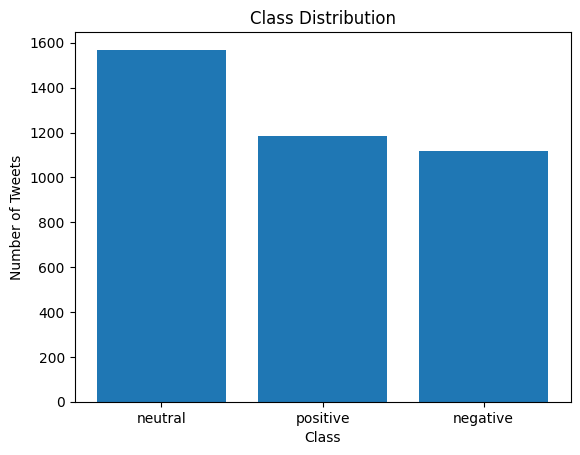

In [2]:
# check class distribution
class_counts = {
    'neutral': len(neutral_df),
    'positive': len(positive_df),
    'negative': len(negative_df),
}
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Tweets')
plt.show()

#### Tweet Length Analysis

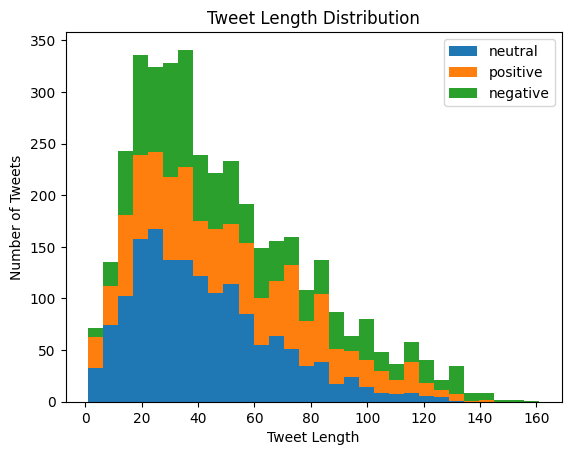

In [3]:
# check tweet length distribution, stacked histogram
plt.hist([neutral_df['tweet'].str.len(), positive_df['tweet'].str.len(), negative_df['tweet'].str.len()], 
         bins=30, stacked=True, label=['neutral', 'positive', 'negative'])
plt.title('Tweet Length Distribution')
plt.xlabel('Tweet Length')
plt.ylabel('Number of Tweets')
plt.legend()
plt.show()